# Prepare and run interface pinning with Chemtrain and LAMMPS


In [1]:
%env JCN_PJRT_PATH=../../software/lib/pjrt
%env NVIDIA_TF32_OVERRIDE=0
%env OEQ_NOTORCH=1
%env JAX_PLATFORMS=cpu

from pathlib import Path
import functools
import os
import shlex
import subprocess
import sys

import e3nn_jax as e3nn
import jax
import jax.numpy as jnp
from jax_md import energy, space

from chemtrain.compose import mace_jax as mace_jax_compose
from chemtrain.deploy import exporter, graphs as export_graphs
from jax_md_mod import custom_partition
from mace_jax.modules import wrapper_ops

jax.config.update("jax_default_matmul_precision", "highest")

TUTORIAL = Path.cwd()
LMP = (TUTORIAL / "../../software/bin/lmp").resolve()
GPU = "0"

env: JCN_PJRT_PATH=../../software/lib/pjrt
env: NVIDIA_TF32_OVERRIDE=0
env: OEQ_NOTORCH=1
env: JAX_PLATFORMS=cpu


/ds/project/paul/projects/chemAiML26/external/chemtrain/chemtrain/__init__.py:35: RuntimeWarning: JAX default matmul precision is not set. For float32 model training, evaluation, and deployment export, consider setting JAX_DEFAULT_MATMUL_PRECISION=highest or jax.config.update('jax_default_matmul_precision', 'highest') for more reproducible matmul/contraction behavior.
  _warn_if_default_matmul_precision_unset()
/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Export the MACE potential


In [2]:
## Load foundational model ##############################################

equivariance_config = wrapper_ops.EquivarianceConfig(
    backend="openeq",
    layout="mul_ir",
    group="O3_e3nn",
    optimize_all=False,
    optimize_channelwise=True,
    optimize_fctp=False,
    conv_fusion=True,
)

# This function uses mace-jax utilities to download the ASL-licensed MACE-MH-1
# foundational model.
torch_model, model_config = mace_jax_compose.load_foundational_model(
    family="mp", version="mh-1"
)
displacement_fn, _ = space.free()
variables, apply_fn = mace_jax_compose.mace_jax_neighborlist_from_torch(
    model_config,
    torch_model,
    displacement_fn,
    max_edge_multiplier=None,
    per_particle=True,
    species_mapping=mace_jax_compose.AtomicNumberMapping(max_number=100),
    scale_pot=1.0,
    scale_pos=1.0,
    equivariance_config=equivariance_config,
    head="matpes_r2scan",
)

## Export foundational model ############################################

class MaceExporter(exporter.Exporter):
    """Export the selected MACE head with its native units."""

    # These arguments specify to the MD engine, how the neighbor list must
    # be computed and which additional ghost particles must be considered
    # on each local processor.
    
    r_cutoff = model_config["r_max"]
    graph_type = export_graphs.SimpleSparseNeighborList
    nbr_order = [model_config["num_interactions"], 2 * model_config["num_interactions"]]

    # The units style is only a consistency check.
    
    unit_style = "metal"
    
    def __init__(self, params, *args, **kwargs):
        self.model = functools.partial(apply_fn, params)
        super().__init__(*args, **kwargs)

    # Only this function is required by the export protocol. Here, we
    # use an utility function to convert the graph into a JAX-MD-like
    # neighbor list object. We apply a species index conversion, and
    # return the per-particle energies.
    
    def energy_fn(self, position, particle_data, graph, comm=None):
        neighbor = graph.to_neighborlist()
        species = particle_data["species"] + 1
        return self.model(position, neighbor, species=species, comm=comm)


mace_model = MaceExporter(variables)
# Custom kernels can accelerate the model, but must be declared explictely
mace_model.export(
    communication=True,
    custom_calls=exporter.OPENEQUIVARIANCE_CUSTOM_CALLS,
)
mace_model.save("mace_mp_mh-1_matpes_r2scan_oeq.ptb")

Using Materials Project MACE for MACECalculator with /home/ga27pej/.cache/mace/macemh1model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


## Export the order parameter and bias


In [3]:
R_ONSET = 4.5
R_CUTOFF = 5.0
L = 6

smooth_cutoff = energy.multiplicative_isotropic_cutoff(
    jnp.ones_like, R_ONSET, R_CUTOFF
)


class SteinhardtOrderExporter(exporter.Exporter):
    """Export the extensive Steinhardt order and pinning bias."""

    graph_type = export_graphs.SimpleSparseNeighborList
    unit_style = "metal"
    has_aux = True
    r_cutoff = R_CUTOFF
    nbr_order = [1, 1]
    global_fields = (
        exporter.GlobalField("steinhardt_kappa", jnp.float32),
        exporter.GlobalField("steinhardt_center", jnp.float32),
    )
    output_fields = (
        exporter.OutputField(
            "steinhardt_order",
            scope=exporter.OutputScope.GLOBAL,
            extensive=True,
        ),
    )

    def _order_parameter(self, position, particle_data, graph, comm):
        n_atoms = position.shape[0]
        vectors, senders, receivers = custom_partition.readout_vectors(
            displacement_fn,
            self.r_cutoff,
            position,
            graph.to_neighborlist(),
            mask=particle_data["valid_mask"],
        )
        squared_distances = jnp.sum(vectors**2, axis=-1)
        distances = jnp.sqrt(jnp.maximum(squared_distances, 1.0e-12))
        weights = smooth_cutoff(distances)

        directions = vectors / distances[:, None]
        harmonics = e3nn.spherical_harmonics(
            L,
            e3nn.IrrepsArray("1o", directions),
            normalize=False,
            normalization="component",
        ).array
        q_lm = jax.ops.segment_sum(
            weights[:, None] * harmonics, senders, n_atoms
        )
        q_norm = jnp.sqrt(
            jnp.maximum(jnp.sum(q_lm**2, axis=-1, keepdims=True), 1.0e-12)
        )
        q_lm /= q_norm
        q_lm = jnp.where(
            particle_data["valid_mask"][:, None], q_lm, 0.0
        )
        if comm is not None:
            q_lm = comm.gather(q_lm)

        correlations = jnp.sum(
            q_lm[senders] * q_lm[receivers], axis=-1
        )
        return jax.ops.segment_sum(
            weights * correlations, senders, n_atoms
        )

    def energy_fn(
        self, position, particle_data, graph, comm=None, global_data=None
    ):
        atom_order = self._order_parameter(
            position, particle_data, graph, comm
        )
        local_mask = particle_data["local_mask"]
        order = jnp.sum(jnp.where(local_mask, atom_order, 0.0))
        atom_count = jnp.sum(local_mask, dtype=position.dtype)
        if comm is not None:
            order = comm.reduce(order)
            atom_count = comm.reduce(atom_count)

        delta = order - global_data["steinhardt_center"]
        bias = 0.5 * global_data["steinhardt_kappa"] * delta**2
        particle_energy = jnp.where(
            local_mask, bias / jnp.maximum(atom_count, 1.0), 0.0
        )
        return particle_energy, {"steinhardt_order": order}


order_model = SteinhardtOrderExporter()
order_model.export(communication=True, custom_calls=())
order_model.save("steinhardt_order_oeq.ptb")

## Prepare the two-phase input


In [4]:
preparation_manifest = TUTORIAL / "input/PREPARATION_OUTPUTS.txt"
preparation_outputs = [
    preparation_manifest.parent / line.strip()
    for line in preparation_manifest.read_text().splitlines()
    if line.strip()
]
missing_preparation_outputs = [path for path in preparation_outputs if not path.is_file()]

if missing_preparation_outputs:
    print("Preparing missing inputs: " + ", ".join(path.name for path in missing_preparation_outputs))
    subprocess.run(
        [sys.executable, "prepare.py", "--gpu", GPU],
        cwd=TUTORIAL,
        check=True,
    )
else:
    print("Preparation is skipped; calibrated inputs are ready.")


CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- KOKKOS package: https://doi.org/10.1145/3731599.3767498
- pair_style chemtrain command: https://doi.org/10.1021/acs.jctc.5c00996 and https://doi.org/10.1016/j.cpc.2025.109512
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 8
  ghost atom cutoff = 14
  binsize = 8, bins = 14 4 4
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair chemtrain/kk, perpetual
      attributes: full, newton on, ghost, kokkos_device
      pair build: full/bin/ghost/kk/device
      stencil: full/ghost/bin/3d
      bin: kk/device
Setting up Verlet run ...
  Unit style    : metal
  Current step  : 0
  Time step     : 0.004
Per MPI rank memory all

## Interface-pinning production


In [5]:
%%writefile pinning_production.lmp

# Run interface pinning from the calibrated two-phase configuration.

# run.py supplies values measured by the preparation stage from TOML.
# Run controls ---------------------------------------------------------------
variable timestep       equal 0.004
variable timeEq         equal 5000
variable timeProd       equal 25000
variable mass           equal 47.867
variable tempMelt       equal ${temperature}
variable defPress       equal ${pressure_gpa}
variable kappa          equal ${kappa_value}
variable folderpath     string ${output_directory}

variable press          equal $(v_defPress*10000)
variable tempDamp       equal 100
variable pressDamp      equal 250

# Load the prepared atoms and calibrated order-parameter center. ------------
timer           loop
units           metal # must match the model units specified during export
dimension       3
boundary        p p p
atom_style      atomic
newton          on
package         kokkos atom/map no
read_data       ${input_data}
mass            * ${mass}

neighbor        2.0 bin
neigh_modify    delay 0 every 1 check yes
timestep        ${timestep}

# Equilibrate and sample with the calibrated interface restraint active.
# We use the following settings:
#     cuda 0.65: Execute on CUDA GPU and preallocate 0.65 of device memory
#     comm on: Exchange node features between domains between message passing steps
#     capacity/atom: Enlarge buffer for atoms per domain by that fraction when overflowed
#     capacity/edge: Similar multiplier for neighborlist edges
#     models main 1 order 1: Compute forces from the MACE moel and the pinning bias
#     global/input order steinhard_kappa <value>: Pass additional float value to the order model
#     global/input order steinhard_center <value>: Similar to before
#     output order steinhard_order: Declare additional model output
pair_style      chemtrain cuda 0.65 & 
                comm on & 
                capacity/atom 1.1 &
                capacity/edge 1.15 &
                models main 1 order 1 &
                global/input order steinhardt_kappa ${kappa} &
                global/input order steinhardt_center ${pinning_center} &
                output order steinhardt_order
# Specify the models in the same order as declared before
pair_coeff      * * ${mace_model} ${order_model}
# Bind the additional model output to a lammps compute
compute         Q all chemtrain/output/kk order steinhardt_order

variable        dx equal lx
variable        dy equal ly
variable        dz equal lz
variable        normalPressure equal pxx

thermo          100
thermo_style    custom step temp press pxx lx ly lz c_Q
thermo_modify   format float %20.16g

# Setup the simulation protocol
fix             ensemble all npt temp ${tempMelt} ${tempMelt} $(v_tempDamp*dt) &
                  x ${press} ${press} $(v_pressDamp*dt)
fix             momentum all momentum 100 linear 1 1 1
fix             eq_out all ave/time 1 1 25 v_dx v_dy v_dz v_normalPressure c_Q &
                  title1 "Biased interface equilibration" &
                  title3 "TimeStep Lx Ly Lz Pxx Q" &
                  format " %20.16g" &
                  file ${folderpath}/interface_equilibration.txt
dump            trajectory all atom 100 ${folderpath}/equilibration.lammpstrj 
run             ${timeEq}
undump          trajectory
unfix           eq_out

fix             prod_out all ave/time 1 1 25 v_dx v_dy v_dz v_normalPressure c_Q &
                  title1 "Biased interface production" &
                  title3 "TimeStep Lx Ly Lz Pxx Q" &
                  format " %20.16g" &
                  file ${folderpath}/interface.txt
dump            trajectory all atom 100 ${folderpath}/interface.lammpstrj
run             ${timeProd}

write_data      ${folderpath}/interface_final.lmpdat


Overwriting pinning_production.lmp


In [6]:
DATA = (TUTORIAL / "input/interface_start.lmpdat").resolve()
PARAMETERS = TUTORIAL / "input/interface_pinning.toml"
RESULTS = (TUTORIAL / "results").resolve()
RESULTS.mkdir(exist_ok=True)

from ip_helpers import load_pinning_parameters

pinning = load_pinning_parameters(PARAMETERS)

pinning["center"] = pinning["production_center"]

pinning

{'q_solid': 27384.4697148438,
 'q_liquid': 5438.52708691406,
 'center': 21897.9840578614,
 'production_center': 21897.9840578614,
 'production_solid_fraction': 0.75,
 'delta_q': 21945.9426279297,
 'crystal_planes': 64,
 'kappa': 1.42249219862905e-06,
 'temperature': 1941,
 'pressure_gpa': 0}

In [7]:
command = [
    str(LMP),
    "-in", "pinning_production.lmp",
    "-k", "on", "g", "1",
    "-sf", "kk",
    "-pk", "kokkos", "newton", "on", "neigh", "half",
    "-var", "input_data", str(DATA),
    "-var", "output_directory", str(RESULTS),
    "-var", "pinning_center", str(pinning["center"]),
    "-var", "kappa_value", str(pinning["kappa"]),
    "-var", "temperature", str(pinning["temperature"]),
    "-var", "pressure_gpa", str(pinning["pressure_gpa"]),
    "-var", "mace_model", str(TUTORIAL / "mace_mp_mh-1_matpes_r2scan_oeq.ptb"),
    "-var", "order_model", str(TUTORIAL / "steinhardt_order_oeq.ptb"),
]

print(shlex.join(command))

/ds/project/paul/projects/chemAiML26/software/bin/lmp -in pinning_production.lmp -k on g 1 -sf kk -pk kokkos newton on neigh half -var input_data /ds/project/paul/projects/chemAiML26/examples/02_diffttc/input/interface_start.lmpdat -var output_directory /ds/project/paul/projects/chemAiML26/examples/02_diffttc/results -var pinning_center 21897.9840578614 -var kappa_value 1.42249219862905e-06 -var temperature 1941 -var pressure_gpa 0 -var mace_model /ds/project/paul/projects/chemAiML26/examples/02_diffttc/mace_mp_mh-1_matpes_r2scan_oeq.ptb -var order_model /ds/project/paul/projects/chemAiML26/examples/02_diffttc/steinhardt_order_oeq.ptb


In [13]:
pinning_manifest = RESULTS / "PINNING_OUTPUTS.txt"
pinning_outputs = [line.strip() for line in pinning_manifest.read_text().splitlines() if line.strip()]
existing_outputs = [RESULTS / name for name in pinning_outputs if (RESULTS / name).exists()]
if existing_outputs:
    names = "\n\t".join(path.name for path in existing_outputs)
    print(f"Skipping interface pinning. Results already exist:\n\t{names}")
else:
    environment = os.environ.copy()
    environment["CUDA_VISIBLE_DEVICES"] = GPU
    environment["JCN_PJRT_PATH"] = str((TUTORIAL / "../../software/lib/pjrt").resolve())
    environment["NVIDIA_TF32_OVERRIDE"] = "0"
    subprocess.run(command, cwd=TUTORIAL, env=environment, check=True)

--------------------------------------------------------------------------
No OpenFabrics connection schemes reported that they were able to be
used on a specific port.  As such, the openib BTL (OpenFabrics
support) will be disabled for this port.

  Local host:           TUMWMFM-SRV01
  Local device:         mlx5_0
  Local port:           1
  CPCs attempted:       udcm
--------------------------------------------------------------------------


LAMMPS (2 Sep 2026)
KOKKOS mode with Kokkos version 5.2.1 is enabled
  using double precision
  using view layout = legacy
  will use up to 1 GPU(s) per node
  using 1 OpenMP thread(s) per MPI task
New timer settings: style=loop  mode=nosync  timeout=off
Reading data file ...
  orthogonal box = (-0.72511984 0 0) to (107.06857 26.583522 26.569861)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  4096 atoms
  reading velocities ...
  4096 velocities
  read_data CPU = 0.021 seconds
chemtrain: JCN API 10, build chemtrain-deploy, XLA 131bf41acb4650e4391a640c3f1859c1c86ad74b (32bed9281ba153c67a75b658e240ddbcd1736e7929ad4ed3d13db691b6bfc9b3)
[JCN] Default log level set to WARNING. Set the JCN_LOGLEVEL environment variable to set a different log level.
[JCN] PJRT plugin directory: /ds/project/paul/projects/chemAiML26/software/lib/pjrt
[JCN] FFI provider directory: /ds/project/paul/projects/chemAiML26/software/lib/ffi
[OpenEquivariance] Registered FFI target tp_forward for CUDA
[OpenEquiv

## Evaluate the interface-pinning run

In [14]:
from IPython.display import display

from ip_helpers import (
    lammps_atom_count,
    load_phase_thermodynamics,
    load_runs,
    melting_temperature_estimate,
    pinning_free_energy_difference,
    plot_evaluation,
    save_figure,
    summary,
)

EQUILIBRATION, PRODUCTION = load_runs(RESULTS)
pinning_for_evaluation = dict(pinning)
pinning_for_evaluation["effective_center"] = pinning["center"]

production_summary = summary(PRODUCTION)
pinning_free_energy = pinning_free_energy_difference(
    pinning, PRODUCTION, lammps_atom_count(DATA)
)
phase_thermodynamics = load_phase_thermodynamics(
    TUTORIAL / "input/phase_thermodynamics.toml"
)
melting_temperature = melting_temperature_estimate(
    pinning_free_energy, phase_thermodynamics
)
{
    "production": production_summary,
    "pinning": pinning_free_energy,
    "melting_temperature": melting_temperature,
}

{'production': {'samples': 1001,
  'blocks': 40,
  'q_mean': 20631.451261628998,
  'q_std': 320.4271612024733,
  'q_block_error': 27.399574445591522},
 'pinning': {'free_energy_difference_kj_per_mol': 3814.888674994507,
  'free_energy_difference_error_kj_per_mol': 82.5295061944658,
  'chemical_potential_difference_kj_per_mol': 0.9313693054185808,
  'chemical_potential_difference_error_kj_per_mol': 0.02014880522325825},
 'melting_temperature': {'reference_temperature_k': 1941.0,
  'chemical_potential_difference_kj_per_mol': 0.9313693054185808,
  'chemical_potential_difference_error_kj_per_mol': 0.02014880522325825,
  'enthalpy_difference_kj_per_mol': -10.13564575704839,
  'entropy_difference_kj_per_mol_k': -0.005701707914717657,
  'melting_temperature_k': 1777.650821236482,
  'melting_temperature_error_from_pinning_k': 3.236422824934222}}

Saved evaluation figures:
  /ds/project/paul/projects/chemAiML26/examples/02_diffttc/results/interface_evaluation.png
  /ds/project/paul/projects/chemAiML26/examples/02_diffttc/results/interface_evaluation.svg


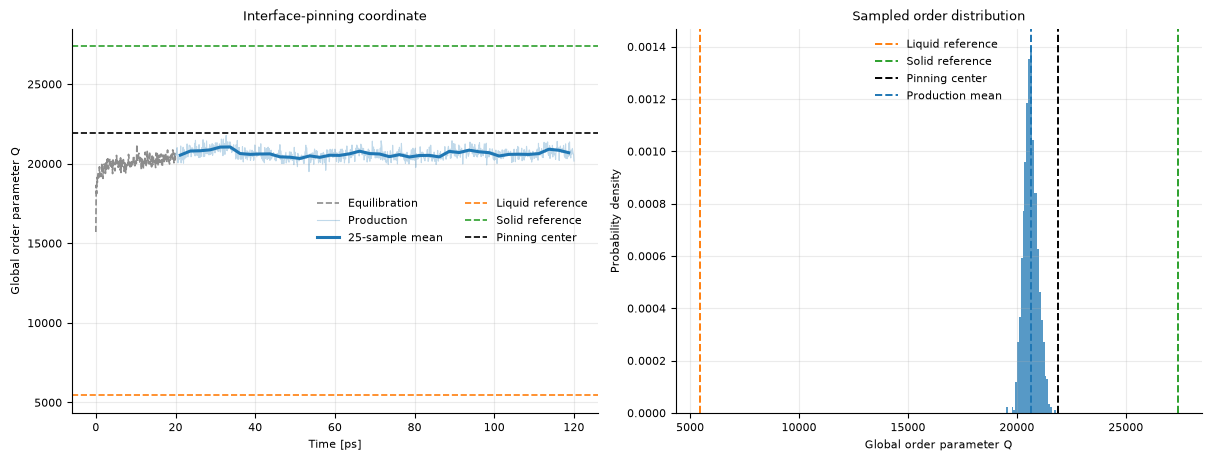

In [15]:
evaluation_figure = plot_evaluation(
    EQUILIBRATION,
    PRODUCTION,
    pinning_for_evaluation,
    timestep_ps=0.004,
)

evaluation_paths = save_figure(evaluation_figure, RESULTS / "interface_evaluation")
print("Saved evaluation figures:", *evaluation_paths, sep="\n  ")

## Inspect the interface trajectory

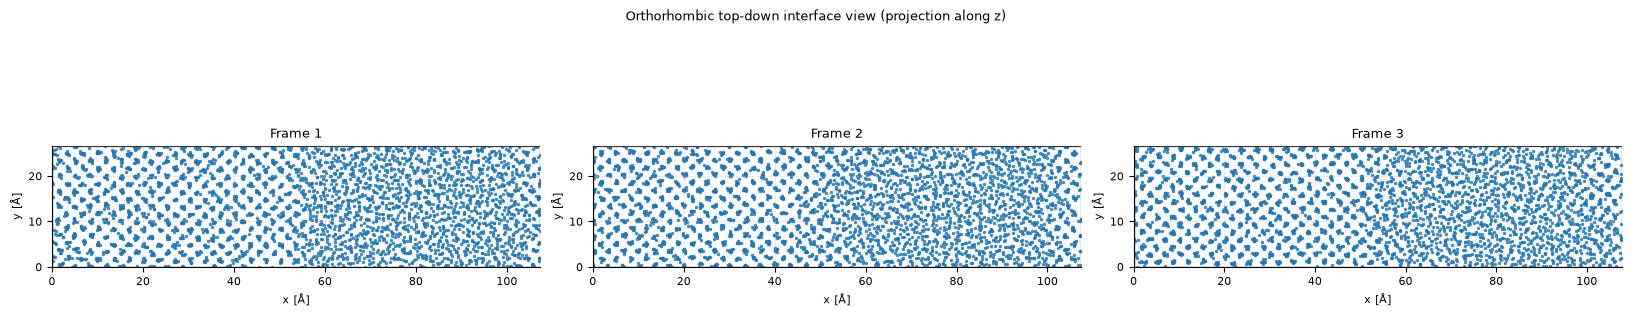

In [16]:
from ip_helpers import load_trajectory_frames, trajectory_view

trajectory_frames = load_trajectory_frames(RESULTS / "interface.lammpstrj")
trajectory_figure = trajectory_view(trajectory_frames)

## Prepare pure phase boxes for DiffTRe

In [17]:
from difftre_helpers import phase_box_paths

MELT_TEMPERATURE = 2500.0

TRAINING = TUTORIAL / "training"
PHASE_BOXES = phase_box_paths(TRAINING)
PHASE_TRAJECTORY = TRAINING / "output/phase_preparation.lammpstrj"
PHASE_BOX_OUTPUTS = (*PHASE_BOXES.values(), TRAINING / "input/phase_boxes.toml", PHASE_TRAJECTORY)
missing_phase_box_outputs = [path for path in PHASE_BOX_OUTPUTS if not path.is_file()]

phase_box_command = [
    str(LMP),
    "-in", str(TRAINING / "prepare_phase_boxes.lmp"),
    "-k", "on", "g", "1",
    "-sf", "kk",
    "-pk", "kokkos", "newton", "on", "neigh", "half",
    "-var", "bcc_output", str(PHASE_BOXES["bcc"]),
    "-var", "liquid_output", str(PHASE_BOXES["liquid"]),
    "-var", "metadata_output", str(TRAINING / "input/phase_boxes.toml"),
    "-var", "trajectory_output", str(PHASE_TRAJECTORY),
    "-var", "mace_model", str(TUTORIAL / "mace_mp_mh-1_matpes_r2scan_oeq.ptb"),
    "-var", "temperature", str(pinning["temperature"]),
    "-var", "pressure_gpa", str(pinning["pressure_gpa"]),
    "-var", "melt_temperature", str(MELT_TEMPERATURE),
]

if missing_phase_box_outputs:
    print("Preparing missing phase boxes: " + ", ".join(path.name for path in missing_phase_box_outputs))
    (TRAINING / "input").mkdir(parents=True, exist_ok=True)
    (TRAINING / "output").mkdir(parents=True, exist_ok=True)
    phase_environment = os.environ.copy()
    phase_environment["CUDA_VISIBLE_DEVICES"] = GPU
    phase_environment["JCN_PJRT_PATH"] = str((TUTORIAL / "../../software/lib/pjrt").resolve())
    subprocess.run(phase_box_command, cwd=TUTORIAL, env=phase_environment, check=True)
else:
    print("Phase-box preparation is skipped; phase boxes are ready.")

Phase-box preparation is skipped; phase boxes are ready.
